# Imports

In [78]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import subprocess
from sklearn.metrics import r2_score

import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# np.set_printoptions(threshold=np.inf)

plt.rcParams["figure.figsize"]=4,4
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message=".*anndata.*", category=FutureWarning)
plt.rcParams["font.family"] = "Arial"
# - dirs 
from hiara.src.config import PLOTS_DIR, datasets_all, aging_clock_train_datasets, aging_clock_train_datasets, palette_genders, palette_treatment, \
        mapping_major_2_minor, mapping_minor_2_major, cell_types, datasets_e, datasets_all, datasets_a, palette_datasets, \
        datasets_disease, datasets_drug_perturbation, OUTPUT_DIR, \
        palette_datasets_pretty, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_major_cts, \
        par_simulation

from hiara.src.feature_association.helper import retrieve_sig_stats, retrieve_net_consensus
from hiara.src.insilico_perturbation.helper import wrapper_in_silico_perturbation
from hiara.src.insilico_perturbation.plots import plot_age_acceleration
from hiara.src.utils.util import get_genesets, get_essential_hallmark
from hiara.src.insilico_perturbation.helper import wrapper_in_silico_single_perturbation

from hiara.src.insilico_perturbation.plots import wrapper_plot_age_acceleration_for_tf_perturbation
from hiara.src.insilico_perturbation.helper import identify_top_tfs
from hiara.src.insilico_perturbation.biological_analysis.helper import plot_pathway_set
n_jobs = 20


cell_types = ['CD4T', 'CD8T'] #['CD4T', 'CD8T',  'NK', 'MONO']
opengenes_pathways = get_genesets('opengenes')
essential_genes = get_genesets('essential')
essential_hallmark = get_essential_hallmark()
gene_score_shift_col = 'gene_score_shift_log2fc'
value_col= 'mean_diff' #'mean_diff' #'z_score'#'signed_neg_log10_pval'

par = par_simulation

# Identify novel rejuvinating TFs

In [2]:
cell_type = 'CD8T'
net = retrieve_net_consensus(cell_type=cell_type)

## Pre-filter TFs

In [3]:
centrality_quantile_threshold = 0.8  # Bottom qnatile

In [4]:
def filter_tfs_by_essentialgenes(net):
    from scipy.stats import fisher_exact

    results = []

    all_targets = set(net['target'])
    all_essentials = set(*essential_genes.values())
    all_non_essentials = all_targets - all_essentials

    for tf, group in net.groupby('source'):
        tf_targets = set(group['target'])
        a = len(tf_targets & all_essentials)
        b = len(tf_targets & all_non_essentials)
        c = len(all_essentials - tf_targets)
        d = len(all_non_essentials - tf_targets)

        table = [[a, b], [c, d]]
        odds, pval = fisher_exact(table, alternative='less')  # or 'less' for depletion
        results.append({'tf': tf, 'odds_ratio': odds, 'pval': pval, 'n_essential_targets': a, 'n_total_targets': len(tf_targets)})

    fisher_df = pd.DataFrame(results)
    from statsmodels.stats.multitest import multipletests
    fisher_df['fdr'] = multipletests(fisher_df['pval'], method='fdr_bh')[1]
    fisher_df = fisher_df[fisher_df['fdr'] < 0.05]
    passed_tfs = fisher_df['tf'].unique()
    return net[net['source'].isin(passed_tfs)]
# - filter one: select tfs that are not central
centrality = net.groupby('source')['target'].count().reset_index()
centrality = centrality.rename(columns={'target': 'n_targets'})
low_central_tfs = centrality[centrality['n_targets'] <= centrality['n_targets'].quantile(centrality_quantile_threshold)]['source']
net_f = net[net['source'].isin(low_central_tfs)]

# - filter two: select tfs that are regulatig essential genes
net_f = filter_tfs_by_essentialgenes(net_f)
net_f['source'].nunique(), net_f['target'].nunique(), net_f.shape

(105, 627, (6582, 3))

In [5]:
TF_all_prefiltered = net_f['source'].unique().tolist()
len(TF_all_prefiltered)

105

### Check the single factor effects

In [6]:
cell_type = 'CD8T'
value_col= 'mean_diff' #'mean_diff' #'z_score'#'signed_neg_log10_pval'
top_n=20

In [8]:
# - retrieve the single tf perturbation results
age_shift_mean = pd.read_csv(f"{OUTPUT_DIR}/perturbation/single_aging_tf_age_shift_mean.csv")
age_shift_mean = age_shift_mean[(age_shift_mean['cell_type']== cell_type) & (age_shift_mean['tf'].isin(TF_all_prefiltered))]

ordered_top_tfs = identify_top_tfs(age_shift_mean, value_col='mean_diff', top_n=top_n)
age_shift_mean = age_shift_mean[age_shift_mean['tf'].isin(ordered_top_tfs)]
age_shift_mean['tf'] = pd.Categorical(age_shift_mean['tf'], categories=ordered_top_tfs, ordered=True)

score_shift_summary = pd.read_csv(f"{OUTPUT_DIR}/perturbation/single_aging_tf_pathway_score_shift.csv")
score_shift_summary = score_shift_summary[(score_shift_summary['cell_type'] == cell_type) & (score_shift_summary['tf'].isin(ordered_top_tfs))]


2.178513438795216


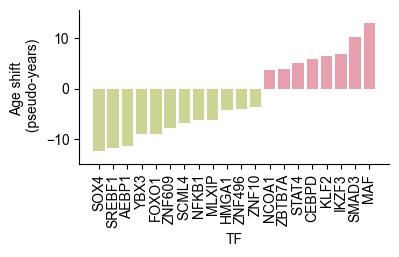

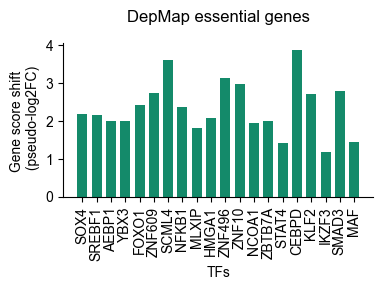

In [31]:
from hiara.src.insilico_perturbation.plots import wrapper_plot_age_acceleration_for_tf_perturbation
from hiara.src.insilico_perturbation.biological_analysis.helper import plot_all

features = None


# - plot age shift 
aa = wrapper_plot_age_acceleration_for_tf_perturbation(age_shift_mean, 
                                        value_col=value_col, 
                                        top_n=top_n,
                                        figsize=(4, 2))
plt.ylabel('Age shift \n (pseudo-years)')
plt.title(f"", pad=15, weight='bold')
plt.savefig(f"{PLOTS_DIR}/insilico_perturbation/ageshift_preselected_tfs.png", bbox_inches='tight', dpi=300)

plot_all(score_shift_summary, gene_score_shift_col, cell_type, ordered_top_tfs, 
            overvap_risky_genes=False, 
            geneshift_opengenes=False,
            geneshift_hallmark=False,
            ageshift_depmap=True
            )

## Look for multi-factor rejuvinating TFs

In [9]:
np.savetxt(f"{OUTPUT_DIR}/candidate_tfs.txt", ordered_top_tfs, fmt="%s") # our search space is very limited (20tfs) -> increase this to all tfs

In [10]:
# - run the analysis
!bash ../../scripts/run_insilico_perturbation.sh

{'step': 1, 'added_tf': 'SOX4', 'tfs': 'SOX4', 'age_shift': -12.32888626274243, 'best_genescore_shift': 2.2059359926247333, 'selected': True}
{'step': 2, 'added_tf': 'SREBF1', 'tfs': 'SOX4,SREBF1', 'age_shift': -20.108677369546392, 'best_genescore_shift': 1.4631013341243058, 'selected': True}
{'step': 3, 'added_tf': 'FOXO1', 'tfs': 'SOX4,SREBF1,FOXO1', 'age_shift': -25.501296588696345, 'best_genescore_shift': 1.0287945531380345, 'selected': True}
{'step': 4, 'added_tf': 'YBX3', 'tfs': 'SOX4,SREBF1,FOXO1,YBX3', 'age_shift': -29.815995773163422, 'best_genescore_shift': 0.8913291085265042, 'selected': True}
{'step': 5, 'added_tf': 'ZNF609', 'tfs': 'SOX4,SREBF1,FOXO1,YBX3,ZNF609', 'age_shift': -33.078925070571, 'best_genescore_shift': 0.6104298827176375, 'selected': True}


In [12]:
optimization_rr = pd.read_csv(f"{OUTPUT_DIR}/optimization_results.csv")
optimization_rr.head()

,step,added_tf,tfs,age_shift,best_genescore_shift,selected
0,1,SOX4,SOX4,-12.328886,2.205936,True
1,2,SREBF1,"SOX4,SREBF1",-20.108677,1.463101,True
2,3,FOXO1,"SOX4,SREBF1,FOXO1",-25.501297,1.028795,True
3,4,YBX3,"SOX4,SREBF1,FOXO1,YBX3",-29.815996,0.891329,True
4,5,ZNF609,"SOX4,SREBF1,FOXO1,YBX3,ZNF609",-33.078925,0.610430,True


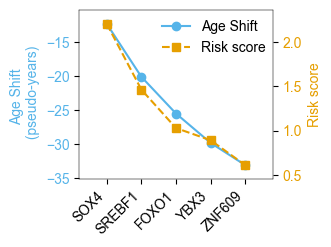

In [98]:
from hiara.src.insilico_perturbation.optimization.helper import plot_greedy_tf_selection
plot_greedy_tf_selection(optimization_rr, figsize=(2.5, 2.2))
plt.savefig(f"{PLOTS_DIR}/insilico_perturbation/optimization_greedy_tf_selection.png", bbox_inches='tight', dpi=300)

In [14]:
selected_tfs = optimization_rr['tfs'][4].split(',')

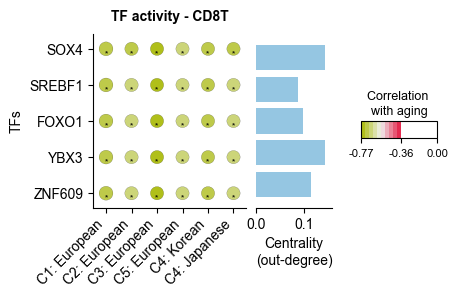

In [94]:
features = selected_tfs
from hiara.src.feature_association.plots import plot_features_vs_datasets
cell_type = 'CD8T'
bb = plot_features_vs_datasets(cell_type=cell_type, type='bulk', datasets=datasets_all, features=features, feature_type='tf_activity', 
                            sizes=(90, 100), width=4,
                            margins_ax1={'x': 0.1, 'y': 0.1}, margins_ax2={'x': 0.1, 'y': 0.07})
plt.savefig(f"{PLOTS_DIR}/insilico_perturbation/feature_association_tf_activity_{cell_type}.png", bbox_inches='tight', dpi=300)

## Pathway score shift due to perturbation

In [15]:
selected_tfs

['SOX4', 'SREBF1', 'FOXO1', 'YBX3', 'ZNF609']

In [16]:
# - run again
raw_rr_store = []
tfs = []
for tf in selected_tfs:
    tfs = tfs + [tf] 
    # - run
    par['tfs'] = tfs
    raw_rr = wrapper_in_silico_perturbation(par, n_jobs=n_jobs, cell_types=[cell_type], datasets=datasets_all)
    # - post run
    raw_rr['tfs'] = ','.join(tfs)
    raw_rr['added_tf'] = tf
    raw_rr_store.append(raw_rr)
raw_rr = pd.concat(raw_rr_store)

In [17]:
from hiara.src.insilico_perturbation.biological_analysis.helper import summarize_pathway_scores
mean_scores = summarize_pathway_scores(raw_rr, cols=['cell_type', 'added_tf'])

In [18]:
mean_scores['added_tf'] = pd.Categorical(
    mean_scores['added_tf'],
    categories=selected_tfs,
    ordered=True
)

In [57]:
from hiara.src.insilico_perturbation.biological_analysis.helper import plot_pathway_score_shift

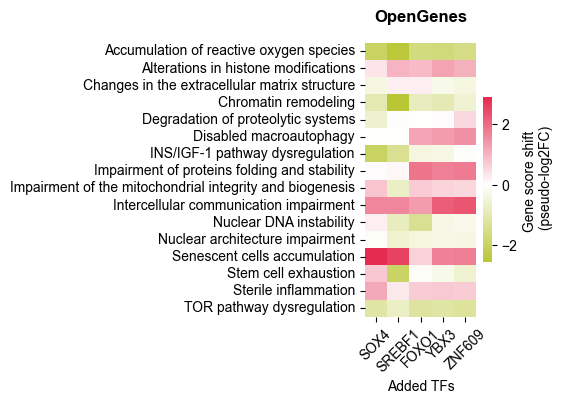

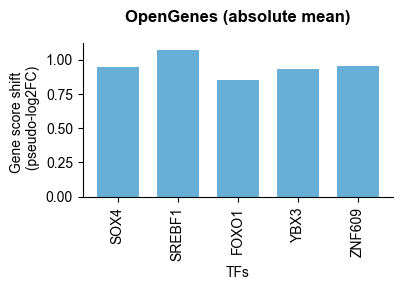

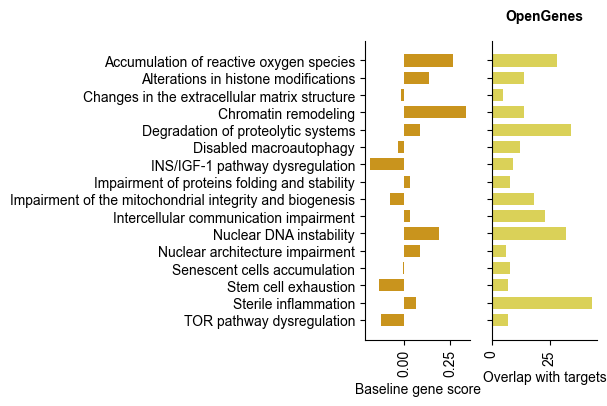

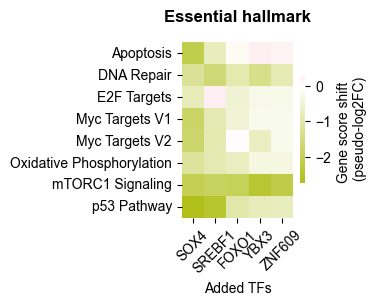

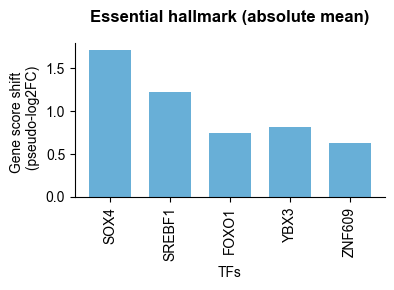

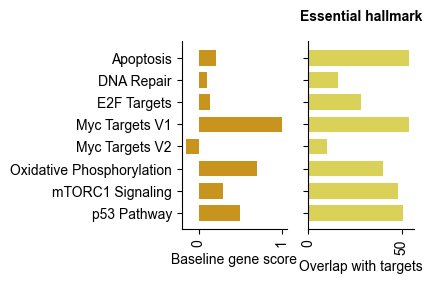

In [91]:
plot_pathway_set(mean_scores, 'opengenes', gene_score_shift_col, cell_type, col_name='added_tf', xlabel='Added TFs', temp_dir=f'{PLOTS_DIR}/insilico_perturbation/')

plot_pathway_set(mean_scores, 'essential_hallmark', gene_score_shift_col, cell_type, col_name='added_tf', xlabel='Added TFs', temp_dir=f'{PLOTS_DIR}/insilico_perturbation/')

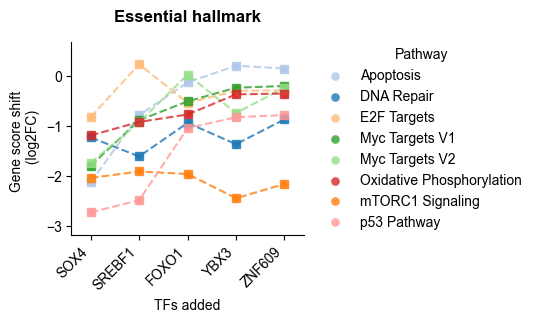

In [75]:
hallmark_terms = list(get_essential_hallmark().keys())
mean_scores_s = mean_scores[mean_scores['pathway'].isin(hallmark_terms)]
plot_pathway_score_shift(mean_scores_s, loc=[1.05, 0])
plt.title(f'Essential hallmark', fontsize=12, weight='bold', pad=15)
plt.savefig(f"{PLOTS_DIR}/insilico_perturbation/essential_hallmark_pathway_score_shift.png", bbox_inches='tight', dpi=300)


In [ ]:
genesets = get_genesets('essential')
mean_scores_s = mean_scores[mean_scores['pathway'].isin(genesets)]
plot_pathway_score_shift(mean_scores_s)
plt.title(f'Essential genes', fontsize=12, weight='bold',  pad=15)


Text(0.5, 1.0, 'OpenGenes pathways')

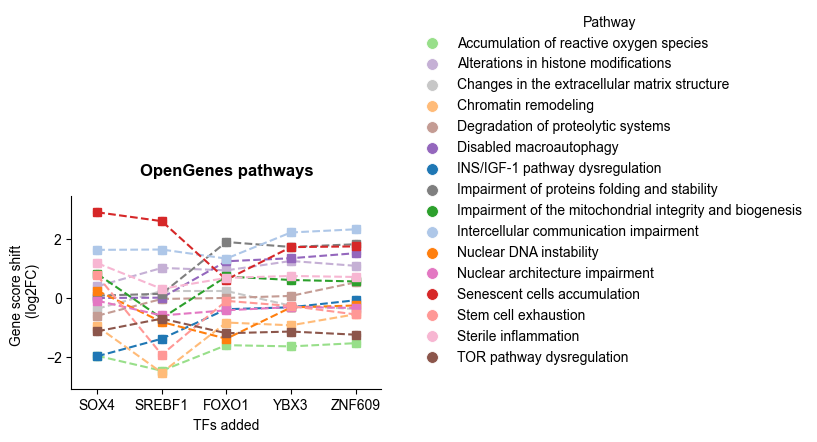

In [61]:
genesets = get_genesets('opengenes')
mean_scores_s = mean_scores[mean_scores['pathway'].isin(genesets)]
plot_pathway_score_shift(mean_scores_s)
plt.title(f'OpenGenes pathways', fontsize=12, weight='bold',  pad=15)